# Imports

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, make_scorer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, BaggingClassifier
)
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
import joblib

# Preprocessing

In [3]:
df = pd.read_csv("epi_r.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20052 entries, 0 to 20051
Columns: 680 entries, title to turkey
dtypes: float64(679), str(1)
memory usage: 104.0 MB


In [5]:
df_nfacts = pd.read_csv("nutrition_facts.csv")
ingridient_list = list(df_nfacts['title'])
ingridient_list.remove('mascarpone')
df_filtered = df[ingridient_list + ['rating']]

In [6]:
df_filtered

,almond,amaretto,anchovy,apple,apple juice,apricot,artichoke,arugula,asian pear,asparagus,...,sweet potato/yam,milk/cream,phyllo/puff pastry dough,hominy/cornmeal/masa,cobbler/crumble,jícama,rosé,wok,saffron,rating
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.500
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.375
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.750
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20047,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.125
20048,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.375
20049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.375
20050,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.375


<Axes: >

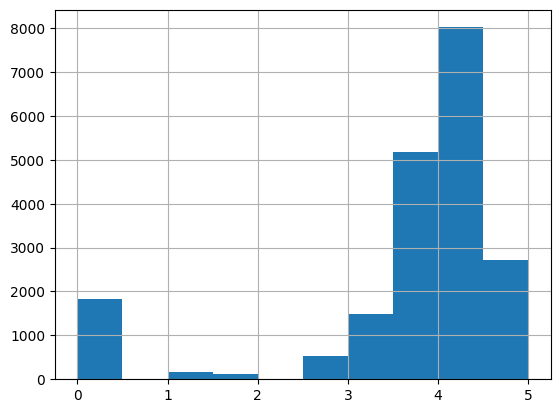

In [7]:
df_filtered['rating'].hist()

In [8]:
feats = [col for col in df_filtered.columns if col != 'rating']
X = df[feats]
y = df['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                random_state=21, stratify=y)

# 1. Regression
## 1.1 Linear regression

In [9]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
np.sqrt(mean_squared_error(y_test, linear_model.predict(X_test)))

np.float64(1.3057350968584531)

## 1.2 Decision Tree

In [10]:
tree_grid = {
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [10, 20, 50],
    'criterion': ['squared_error', 'friedman_mse'],
    'max_features': ['sqrt', 'log2']
}

tree_model = DecisionTreeRegressor(random_state=42)
gs = GridSearchCV(
    estimator=tree_model,
    param_grid=tree_grid,
    scoring='neg_root_mean_squared_error',
    cv = 10,
    n_jobs=-1,
    verbose=1)
gs.fit(X_train, y_train)

Fitting 10 folds for each of 144 candidates, totalling 1440 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'friedman_mse'], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [10, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [11]:
tree_df = pd.DataFrame(gs.cv_results_)
tree_df = tree_df.sort_values('mean_test_score', ascending=False)
print(tree_df[['params', 'mean_test_score', 'std_test_score']].head())

                                                params  mean_test_score  \
126  {'criterion': 'friedman_mse', 'max_depth': 20,...        -1.316247   
54   {'criterion': 'squared_error', 'max_depth': 20...        -1.316247   
127  {'criterion': 'friedman_mse', 'max_depth': 20,...        -1.316247   
128  {'criterion': 'friedman_mse', 'max_depth': 20,...        -1.316247   
56   {'criterion': 'squared_error', 'max_depth': 20...        -1.316247   

     std_test_score  
126         0.02778  
54          0.02778  
127         0.02778  
128         0.02778  
56          0.02778  


In [12]:
tree_df['params'][0]

{'criterion': 'squared_error',
 'max_depth': 3,
 'max_features': 'sqrt',
 'min_samples_leaf': 10,
 'min_samples_split': 2}

### Decision Tree - оценка качества

In [13]:
tree_model = DecisionTreeRegressor(
    random_state=42,
    criterion='squared_error',
    max_depth=3,
    max_features='sqrt',
    min_samples_leaf=10,
    min_samples_split=2)
tree_model.fit(X_train, y_train)
np.sqrt(mean_squared_error(y_test, tree_model.predict(X_test)))


np.float64(1.3354369483966622)

## 1.3 Random Forest

In [14]:
rf_grid = {
    'max_features': ["sqrt", "log2"],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
}
rf_model = RandomForestRegressor(
    random_state=42,
    max_depth=1,
    n_estimators=5)

gs = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_grid,
    scoring='neg_root_mean_squared_error',
    cv = 4,
    n_jobs=-1,
    verbose=1)
gs.fit(X_train, y_train)

Fitting 4 folds for each of 18 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [15]:
rf_df = pd.DataFrame(gs.cv_results_)
rf_df = rf_df.sort_values('mean_test_score', ascending=False)
print(rf_df[['params', 'mean_test_score', 'std_test_score']].head())
rf_df['params'][0]

                                               params  mean_test_score  \
10  {'max_features': 'log2', 'min_samples_leaf': 1...        -1.338488   
9   {'max_features': 'log2', 'min_samples_leaf': 1...        -1.338488   
11  {'max_features': 'log2', 'min_samples_leaf': 1...        -1.338488   
0   {'max_features': 'sqrt', 'min_samples_leaf': 1...        -1.338550   
1   {'max_features': 'sqrt', 'min_samples_leaf': 1...        -1.338550   

    std_test_score  
10        0.012877  
9         0.012877  
11        0.012877  
0         0.012709  
1         0.012709  


{'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}

### Random forest - оценка качества

In [16]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=5,
    max_depth=1,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
)
rf_model.fit(X_train, y_train)
np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test)))

np.float64(1.3387743253136912)

In [17]:
def plot_regression_results(X, y, models):
    num_models = len(models)
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5), squeeze=False)
    
    for ax, (name, model_obj) in zip(axes.ravel(), models.items()):
        y_pred = cross_val_predict(model_obj, X, y, cv=10)
        
        sns.scatterplot(x=y[0:200], y=y_pred[0:200], ax=ax, alpha=0.6)
        
        line_coords = [y.min(), y.max()]
        ax.plot(line_coords, line_coords, color='red', linestyle='--')
        
        ax.set_title(f'{name}')
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')

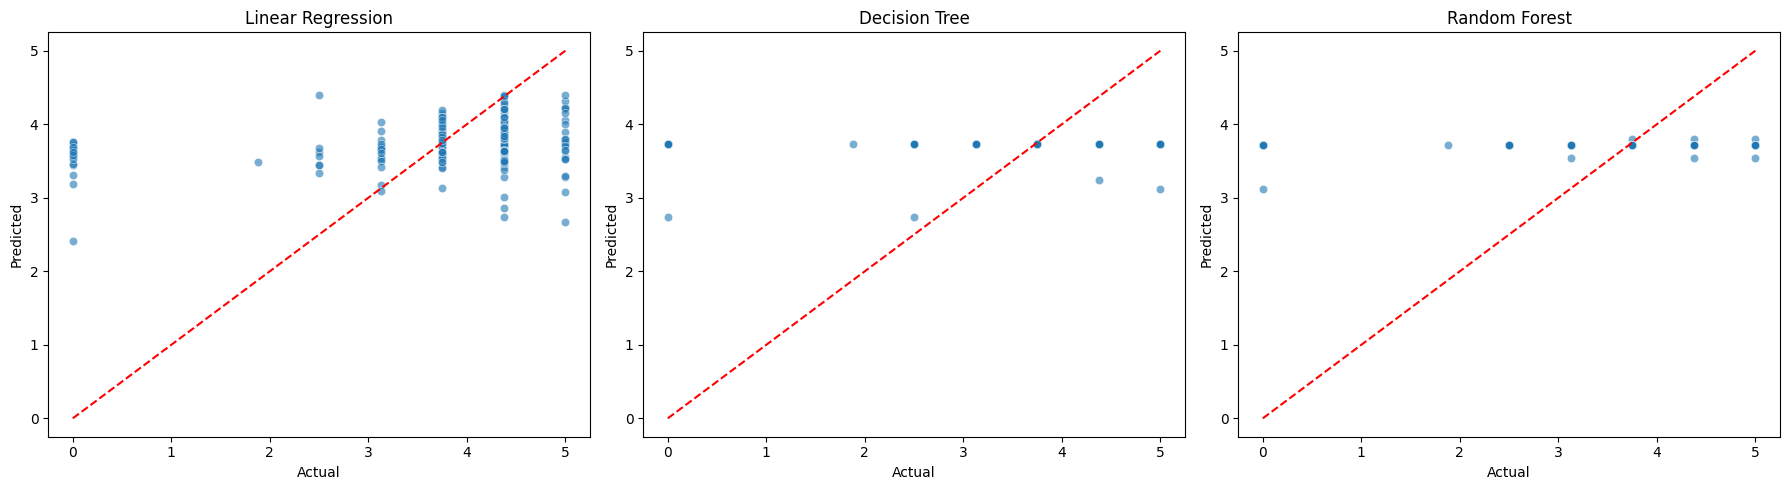

In [18]:
plot_regression_results(X, y, {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model})
plt.tight_layout()
plt.show()

## Naive

In [19]:
y_mean = y_train.mean()
y_pred_naive = np.full_like(y_test, fill_value=y_mean, dtype=float)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
rmse_naive

np.float64(1.3406047401708432)

# Classification

In [20]:
df_filtered = df[ingridient_list + ['rating']].copy()
df_filtered["rounded_rating"] = df_filtered["rating"].round().astype(int)
df_filtered.head(5)

,almond,amaretto,anchovy,apple,apple juice,apricot,artichoke,arugula,asian pear,asparagus,...,milk/cream,phyllo/puff pastry dough,hominy/cornmeal/masa,cobbler/crumble,jícama,rosé,wok,saffron,rating,rounded_rating
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.500,2
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.375,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.750,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000,5
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.125,3


In [21]:
y = df_filtered['rounded_rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                random_state=21, stratify=y)

In [22]:
X_sub = X_train.sample(frac=0.1, random_state=42)
y_sub = y_train.loc[X_sub.index]

param_grid = {
    "kernel": ("linear", "rbf", "sigmoid"),
    "C": (0.1, 1, 10),
    "gamma": ("scale", "auto"),
    "class_weight": ("balanced", None),
    }

gs = GridSearchCV(
    estimator=SVC(random_state=21, probability=True),
    param_grid=param_grid,
    n_jobs=-1,
    verbose=1,
    cv=4
    )
gs.fit(X_sub, y_sub)

result_df = pd.DataFrame(gs.cv_results_)
result_df = result_df.sort_values('mean_test_score',
                ascending=False).reset_index(drop=True)
print(f"SVM params: {result_df['params'][0]}")

Fitting 4 folds for each of 36 candidates, totalling 144 fits
SVM params: {'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}


In [23]:
param_grid = {
    "max_depth": [5, 10, 20, 30],
    "class_weight": ("balanced", None),
    "criterion": ("entropy", "gini")
    }

gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=21),
                  param_grid=param_grid,
                  n_jobs=-1,
                  verbose=1)
gs.fit(X_train, y_train)

result_df = pd.DataFrame(gs.cv_results_)
result_df = result_df.sort_values('mean_test_score',
                ascending=False).reset_index(drop=True)
print(f"Tree params: {result_df['params'][0]}")

param_grid = {
        "n_estimators": [20, 50, 150],
        "criterion": ["gini", "entropy"],
        "max_depth": [30, 50, 60],
        "class_weight": [None, "balanced"],
    }

gs = GridSearchCV(estimator=RandomForestClassifier(random_state=21),
                  param_grid=param_grid,
                  n_jobs=-1,
                  verbose=1,
                  cv=4)
gs.fit(X_train, y_train)

result_df = pd.DataFrame(gs.cv_results_)
result_df = result_df.sort_values('mean_test_score',
                ascending=False).reset_index(drop=True)
print(f"Forest params: {result_df['params'][0]}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Tree params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5}
Fitting 4 folds for each of 36 candidates, totalling 144 fits
Forest params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 50, 'n_estimators': 150}


In [24]:
X_sub = X_train.sample(frac=0.2, random_state=42)
y_sub = y_train.loc[X_sub.index]
svm_model = SVC(
    random_state=21,
    probability=True,
    C=1,
    class_weight=None,
    gamma='scale',
    kernel='sigmoid'
    )
svm_model.fit(X_sub, y_sub)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
accuracy_score(y_test, svm_model.predict(X_test))

0.6644228371977063

In [26]:
tree_model = DecisionTreeClassifier(
    class_weight=None,
    criterion='gini',
    max_depth=10,
    random_state=21
)
tree_model.fit(X_train, y_train)
accuracy_score(y_test, tree_model.predict(X_test))

0.6671652954375468

In [27]:
rf_model = RandomForestClassifier(
    class_weight=None,
    criterion='gini',
    max_depth=50,
    n_estimators=150,
    random_state=21,
)
rf_model.fit(X_train, y_train)
accuracy_score(y_test, rf_model.predict(X_test))

0.6743954126153079

# Naive classifier

In [28]:
y_naive = np.full_like(y_test, fill_value=y_train.mode()[0])
accuracy_score(y_test, y_naive)

0.6576913487908252

# Binary Classification

In [29]:
df_filtered['target_class'] = df_filtered['rounded_rating'].apply(
    lambda x: "great" if x >= 4 else "so so" if x >= 2 else "bad"
)
df_bin_class = df_filtered[ingridient_list + ['target_class']].copy()
df_bin_class.head()

,almond,amaretto,anchovy,apple,apple juice,apricot,artichoke,arugula,asian pear,asparagus,...,sweet potato/yam,milk/cream,phyllo/puff pastry dough,hominy/cornmeal/masa,cobbler/crumble,jícama,rosé,wok,saffron,target_class
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,so so
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,great
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,great
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,great
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,so so


In [30]:
X_cls = df_bin_class[ingridient_list]
y_cls = df_bin_class['target_class']

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=21, stratify=y_cls
)

print(f'\nTrain size: {X_cls_train.shape[0]}, Test size: {X_cls_test.shape[0]}')


Train size: 16041, Test size: 4011


In [31]:
grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=21),
        {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'class_weight': ['balanced', None]},
        X_cls_train, y_cls_train
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=21),
        {'max_depth': [3, 5, 7, 10, 15, 20],
         'min_samples_leaf': [1, 5, 10, 20],
         'criterion': ['entropy', 'gini'],
         'class_weight': ['balanced', None]},
        X_cls_train, y_cls_train
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=21),
        {'n_estimators': [100, 200],
         'max_depth': [5, 10, 20, None],
         'min_samples_leaf': [1, 5, 10],
         'class_weight': ['balanced', None]},
        X_cls_train, y_cls_train
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 11, 15, 21, 31],
         'weights': ['uniform', 'distance'],
         'metric': ['euclidean', 'manhattan']},
        X_cls_train, y_cls_train
    )
}

gs_results = {}
for name, (estimator, param_grid, X_fit, y_fit) in grids.items():
    gs_cv = GridSearchCV(estimator=estimator, param_grid=param_grid,
                         cv=5, scoring='accuracy', verbose=0, n_jobs=-1).fit(X_fit, y_fit)
    gs_results[name] = gs_cv
    print(f'{name}  лучшая CV accuracy={gs_cv.best_score_}  params={gs_cv.best_params_}')

best_tuned_name = max(gs_results, key=lambda n: gs_results[n].best_score_)
best_tuned_model = gs_results[best_tuned_name].best_estimator_
print(f'\nЛучшая модель в результате тюнинга - {best_tuned_name}')
print(f'Лучшие параметры: {gs_results[best_tuned_name].best_params_}')

Logistic Regression  лучшая CV accuracy=0.7987655899204933  params={'C': 1, 'class_weight': None}
Decision Tree  лучшая CV accuracy=0.7985785186457353  params={'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1}
Random Forest  лучшая CV accuracy=0.7998877067225983  params={'class_weight': None, 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
KNN  лучшая CV accuracy=0.797705992109163  params={'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}

Лучшая модель в результате тюнинга - Random Forest
Лучшие параметры: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}


In [32]:
y_cls_pred = best_tuned_model.predict(X_cls_test)
best_test_accuracy = accuracy_score(y_cls_test, y_cls_pred)

dummy = DummyClassifier(strategy='most_frequent', random_state=21).fit(X_cls_train, y_cls_train)
naive_accuracy = accuracy_score(y_cls_test, dummy.predict(X_cls_test))

summary = pd.DataFrame({
    "Модель": ["Наивный классификатор (по моде)", best_tuned_name],
    "Accuracy": [naive_accuracy, best_test_accuracy]
})
summary = summary.set_index("Модель")

print(summary.to_string())
print(f"\nУлучшение по сравнению с наивным классификатором: {best_test_accuracy - naive_accuracy}")

                                 Accuracy
Модель                                   
Наивный классификатор (по моде)  0.793318
Random Forest                    0.798554

Улучшение по сравнению с наивным классификатором: 0.005235602094240899


**С наивным классификатором мы ошибочно распознаем положительный результат (рецепт "великолепен", great), поскольку он встречается наиболее часто, что плохо: лучше ошибочно классифицировать рецепт как плохой, нежели как хороший (ошибка принесет меньше ущерба тому, кто попробует рецепт). Поскольку датасет неуравновешен ("великолепных" рецептов даже больше, чем остальных, вместе взятых), наивный классификатор показывает вполне хорошие показатели accuracy. Однако accuracy не позволяет оценить, насколько надежны позитивные предсказания модели. Для нас важно, чтобы среди рецептов, предсказанных как "великолепные", действительно как можно больше оказывались таковыми - иными словами, нужно максимизировать precision класса 'great'. Мы будем использовать эту метрику при подборе гиперпараметров.**

In [33]:
def _precision_great(y_true, y_pred):
    return precision_score(y_true, y_pred, labels=['great'], average='macro', zero_division=0)

great_precision_scorer = make_scorer(_precision_great)

gs_results = {}
for name, (estimator, param_grid, X_fit, y_fit) in grids.items():
    gs_cv = GridSearchCV(estimator=estimator, param_grid=param_grid,
                         cv=5, scoring=great_precision_scorer, verbose=0, n_jobs=-1).fit(X_fit, y_fit)
    gs_results[name] = gs_cv
    print(f'{name}  лучшая CV precision (\'great\')={gs_cv.best_score_}  params={gs_cv.best_params_}')

best_tuned_name = max(gs_results, key=lambda n: gs_results[n].best_score_)
best_tuned_model = gs_results[best_tuned_name].best_estimator_
print(f'\nЛучшая модель в результате тюнинга - {best_tuned_name}')
print(f'Лучшие параметры: {gs_results[best_tuned_name].best_params_}')

Logistic Regression  лучшая CV precision ('great')=0.8513174768375442  params={'C': 0.01, 'class_weight': 'balanced'}
Decision Tree  лучшая CV precision ('great')=0.918630898415115  params={'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1}
Random Forest  лучшая CV precision ('great')=0.8564505371539344  params={'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 200}
KNN  лучшая CV precision ('great')=0.8159818369576609  params={'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Лучшая модель в результате тюнинга - Decision Tree
Лучшие параметры: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1}


In [34]:
ensemble_grids = {
    'Extra Trees': (
        ExtraTreesClassifier(random_state=21),
        {'n_estimators': [100, 200],
         'max_depth': [5, 10, 20, None],
         'min_samples_leaf': [1, 5, 10],
         'class_weight': ['balanced', None]},
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=21),
        {'n_estimators': [100, 200],
         'max_depth': [2, 3, 5],
         'learning_rate': [0.01, 0.05, 0.1, 0.2],
         'subsample': [0.7, 0.8, 1.0]},
    ),
    'AdaBoost': (
        AdaBoostClassifier(random_state=21),
        {'n_estimators': [50, 100, 200],
         'learning_rate': [0.01, 0.1, 0.5, 1.0]},
    ),
    'Bagging': (
        BaggingClassifier(random_state=21),
        {'n_estimators': [50, 100, 200],
         'max_samples': [0.5, 0.8, 1.0],
         'max_features': [0.5, 0.8, 1.0]},
    )
}

ens_results = {}
for name, (estimator, param_grid) in ensemble_grids.items():
    gs_cv = GridSearchCV(
        estimator=estimator, param_grid=param_grid,
        cv=5, scoring=great_precision_scorer, n_jobs=-1, verbose=0
    ).fit(X_cls_train, y_cls_train)
    ens_results[name] = gs_cv
    print(f'{name}  precision (\'great\')={gs_cv.best_score_}  params={gs_cv.best_params_}')

best_ens_name  = max(ens_results, key=lambda n: ens_results[n].best_score_)
best_ens_model = ens_results[best_ens_name].best_estimator_
best_ens_score = ens_results[best_ens_name].best_score_
print(f'\nЛучший ансамбль: {best_ens_name}')
print(f"CV precision ('great'): {best_ens_score}")
print(f'Параметры: {ens_results[best_ens_name].best_params_}')

Extra Trees  precision ('great')=0.864523711423954  params={'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
Gradient Boosting  precision ('great')=0.8061044020981922  params={'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}
AdaBoost  precision ('great')=0.7996365356988273  params={'learning_rate': 0.5, 'n_estimators': 200}
Bagging  precision ('great')=0.8162354475273208  params={'max_features': 1.0, 'max_samples': 0.8, 'n_estimators': 100}

Лучший ансамбль: Extra Trees
CV precision ('great'): 0.864523711423954
Параметры: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}


## Decision

In [35]:
final_pipeline = Pipeline([
    ('preprocessor', VarianceThreshold(threshold=0.0)),
    ('clf', DecisionTreeClassifier(
        class_weight='balanced', criterion='gini',
        max_depth=5, min_samples_leaf=1, random_state=21
    ))
])

final_pipeline.fit(X_cls_train, y_cls_train)

y_final_pred = final_pipeline.predict(X_cls_test)
print(f"Финальная модель (пайплайн) - accuracy: {accuracy_score(y_cls_test, y_final_pred):.4f}")
print(f"Финальная модель (пайплайн) - precision ('great'): {_precision_great(y_cls_test, y_final_pred):.4f}")

joblib.dump(final_pipeline, 'best_model.pkl')

Финальная модель (пайплайн) - accuracy: 0.6699
Финальная модель (пайплайн) - precision ('great'): 0.7968


['best_model.pkl']